# **Python performance with and without NumPy**

The code in this notebook was made for Programming Assigment #1. A comparison of execution time between plain Python and NumPy in vector and matrix multiplications.



This cell block just sets up initial values, such as the libraries that will be used, the randomizer seed, the sizes for both vectors and matrices and finally the trials

In [ ]:
#Libraries and set up variables

import time
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)
dtype = np.float64
vector_sizes = [10, 50, 100, 200, 500]
matrix_sizes = [10, 50, 100, 200, 500]
trials = 15

This cell block defines two Python-based multiplication functions, one for vectors and one for matrices. It does the multiplication by using for loops (triple for loop algorithm in the case of the matrices).

In [ ]:
#Functions for python multiplications
def python_vector_multiply(a, b):
    result = [0.0] * len(a)
    for i in range(len(a)):
        result[i] = a[i] * b[i]
    return result


def python_matrix_multiply(A, B):
    n = len(A)
    result = [[0.0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            for k in range(n):
                result[i][j] += A[i][k] * B[k][j]

    return result

This cell block defines NumPy-based multiplication, similarly, one function is for vectors the other for matrices.

In [ ]:
#Functions for NumPy multiplications
def numpy_vector_multiply(a, b):
    return a * b


def numpy_matrix_multiply(A, B):
    return A @ B

This cell block defines a function to measure how long another function takes to run. It runs the function multiple times and returns the median execution time. It accepts the function to be measured as the `func` argument, any arguments to be pased to send function in `*args`, and finally the amount of `trials`.



In [ ]:
#Function to time multiplication functions (the function to be timed is pased as an argument)
def time_function(func, *args, trials=15):
    times = []

    # Warm-up
    func(*args)

    for _ in range(trials):
        start = time.perf_counter()
        func(*args)
        end = time.perf_counter()
        times.append(end - start)

    return np.median(times)

This cell block runs an experiment comparing Python and NumPy vector multiplication.

For each vector size, it creates random vectors as both Python lists and NumPy arrays.

It checks that the Python and NumPy results are the same.

Then it measures the time each method takes using time_function.

Finally, it stores the size and both timings in vector_results.

In [ ]:
#Vector Multiplications Experiment
vector_results = []

for n in vector_sizes:
    # Create data outside timed region
    a_list = list(np.random.rand(n))
    b_list = list(np.random.rand(n))

    a_np = np.array(a_list, dtype=dtype)
    b_np = np.array(b_list, dtype=dtype)

    # Correctness check
    py_res = python_vector_multiply(a_list, b_list)
    np_res = numpy_vector_multiply(a_np, b_np)

    assert np.allclose(py_res, np_res)

    # Timing
    t_py = time_function(python_vector_multiply, a_list, b_list, trials=trials)
    t_np = time_function(numpy_vector_multiply, a_np, b_np, trials=trials)

    vector_results.append((n, t_py, t_np))

vector_results

[(10, np.float64(7.960006769280881e-07), np.float64(4.949997673975304e-07)),
 (50, np.float64(2.877000042644795e-06), np.float64(5.089996193419211e-07)),
 (100, np.float64(5.4279998948914e-06), np.float64(4.929997885483317e-07)),
 (200, np.float64(1.0678000762709416e-05), np.float64(5.499996404978447e-07)),
 (500, np.float64(2.8079000003344845e-05), np.float64(5.780002538813278e-07))]

This cell block runs an experiment comparing Python and NumPy matrix multiplication.

For each matrix size, it creates random matrices as both Python lists and NumPy arrays.

It checks that the Python and NumPy results are the same.

Then it measures the time each method takes using time_function.

Finally, it stores the size and both timings in matrix_results.

In [ ]:
#Matrix Multiplication EXperiment
matrix_results = []

for n in matrix_sizes:
    print(f"Running size {n}x{n}...")
    # Create data
    A_list = list(np.random.rand(n, n))
    B_list = list(np.random.rand(n, n))

    A_np = np.array(A_list, dtype=dtype)
    B_np = np.array(B_list, dtype=dtype)

    # Correctness check
    py_res = python_matrix_multiply(A_list, B_list)
    np_res = numpy_matrix_multiply(A_np, B_np)

    assert np.allclose(py_res, np_res)

    # Timing
    t_py = time_function(python_matrix_multiply, A_list, B_list, trials=trials)
    t_np = time_function(numpy_matrix_multiply, A_np, B_np, trials=trials)

    matrix_results.append((n, t_py, t_np))

matrix_results

Running size 10x10...
Running size 50x50...
Running size 100x100...
Running size 200x200...
Running size 500x500...


[(10, np.float64(0.00017801699959818507), np.float64(1.0390003808424808e-06)),
 (50, np.float64(0.02086132299973542), np.float64(5.083999894850422e-06)),
 (100, np.float64(0.16347638400020514), np.float64(3.181899955961853e-05)),
 (200, np.float64(1.3462754080001105), np.float64(8.35170003483654e-05)),
 (500, np.float64(20.22367862400006), np.float64(0.0011382800003048033))]

This cell block plots the median runtime of Python vs. NumPy for different vector sizes. It shows how Python and NumPy compare for element-wise vector multiplication.

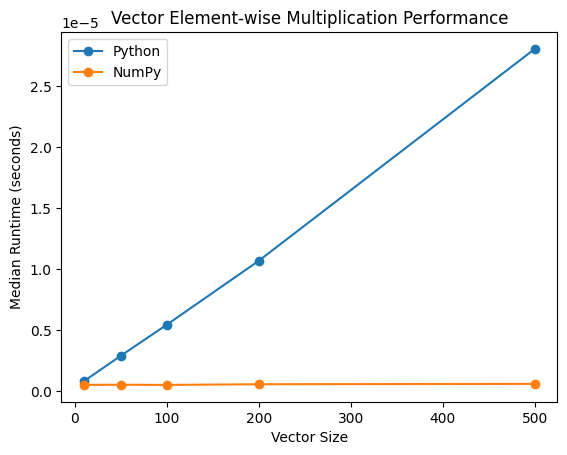

In [ ]:
#Plot for vector multiplication performance
v_sizes = [r[0] for r in vector_results]
v_python_times = [r[1] for r in vector_results]
v_numpy_times = [r[2] for r in vector_results]

plt.figure()
plt.plot(v_sizes, v_python_times, marker='o', label="Python")
plt.plot(v_sizes, v_numpy_times, marker='o', label="NumPy")
plt.xlabel("Vector Size")
plt.ylabel("Median Runtime (seconds)")
plt.title("Vector Element-wise Multiplication Performance")
plt.legend()
plt.show()

SImilarly to the one before, this cell block plots the median runtime of Python vs. NumPy for different matrix sizes.

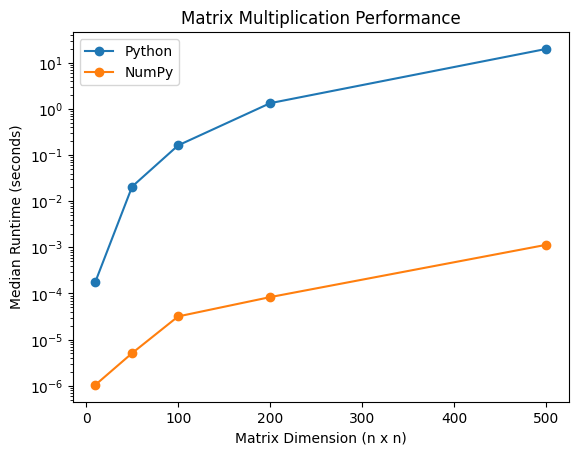

In [ ]:
#Plot for matrix multiplication performance
m_sizes = [r[0] for r in matrix_results]
m_python_times = [r[1] for r in matrix_results]
m_numpy_times = [r[2] for r in matrix_results]

plt.figure()
plt.plot(m_sizes, m_python_times, marker='o', label="Python")
plt.plot(m_sizes, m_numpy_times, marker='o', label="NumPy")
plt.xlabel("Matrix Dimension (n x n)")
plt.ylabel("Median Runtime (seconds)")
plt.title("Matrix Multiplication Performance")
plt.yscale("log")
plt.legend()
plt.show()

This cell block plots the speedup of NumPy over Python for vector multiplication. The speedup is calculated as Python time ÷ NumPy time and shows how many times faster NumPy is.

Text(0.5, 1.0, 'NumPy Speedup Over Pure Python for Vector Multiplication')

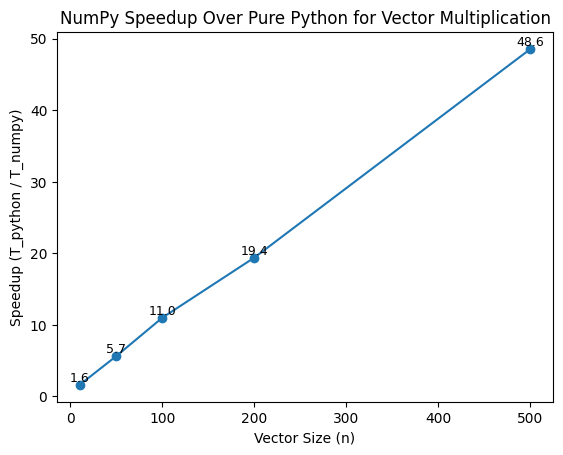

In [ ]:
#Plot for vector speedup
vector_speedup = [py/np for (_, py, np) in vector_results]

plt.figure()
plt.plot(v_sizes, vector_speedup, marker='o')

for i, speed in enumerate(vector_speedup):
    plt.text(v_sizes[i], speed, f"{speed:.1f}", ha='center', va='bottom', fontsize=9)

plt.xlabel("Vector Size (n)")
plt.ylabel("Speedup (T_python / T_numpy)")
plt.title("NumPy Speedup Over Pure Python for Vector Multiplication")

This cell block plots the speedup of NumPy over Python for matrix multiplication. The speedup is calculated the same way as previously mentioned.

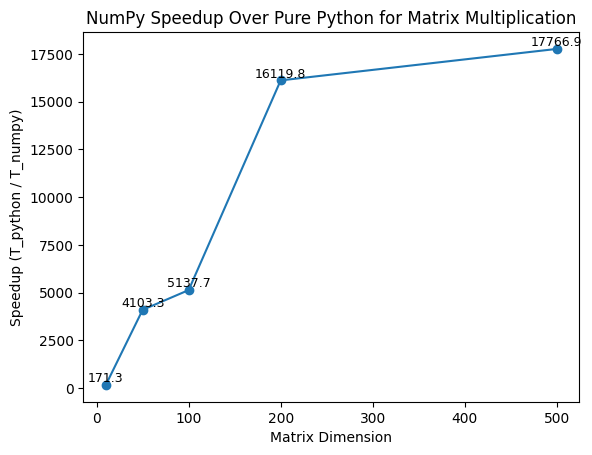

In [ ]:
#Plot for matrix speedup
matrix_speedups = [py/np for (_, py, np) in matrix_results]

plt.figure()
plt.plot(m_sizes, matrix_speedups, marker='o')

for i, speed in enumerate(matrix_speedups):
    plt.text(m_sizes[i], speed, f"{speed:.1f}", ha='center', va='bottom', fontsize=9)


plt.xlabel("Matrix Dimension")
plt.ylabel("Speedup (T_python / T_numpy)")
plt.title("NumPy Speedup Over Pure Python for Matrix Multiplication")
plt.show()